In [576]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from sklearn.preprocessing import MinMaxScaler,OrdinalEncoder
from sklearn.model_selection import train_test_split

In [577]:
raw_data = pd.read_csv("./crx.data", header=None, na_values='?')

cont_attr = [1,2,7,10,13,14]
dis_attr = []
for i in range(15):
    if not i in cont_attr:
        dis_attr.append(i)
        
raw_data

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,202.0,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,43.0,560,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,280.0,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,100.0,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,120.0,0,+
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
685,b,21.08,10.085,y,p,e,h,1.25,f,f,0,f,g,260.0,0,-
686,a,22.67,0.750,u,g,c,v,2.00,f,t,2,t,g,200.0,394,-
687,a,25.25,13.500,y,p,ff,ff,2.00,f,t,1,t,g,200.0,1,-
688,b,17.92,0.205,u,g,aa,v,0.04,f,f,0,f,g,280.0,750,-


In [578]:
for index in range(15):
    if index in cont_attr:
        _mean = raw_data[index].mean()
        raw_data[index] = raw_data[index].replace(math.nan,_mean)
    else:
        _mode = raw_data[index].mode()[0]
        raw_data[index] = raw_data[index].replace(math.nan,_mode)
        
raw_data.isna().sum()

0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
dtype: int64

In [579]:
min_max_scaler = MinMaxScaler()
x = raw_data[cont_attr].values
x_scaled = min_max_scaler.fit_transform(x)

normalized = pd.DataFrame(x_scaled, columns=cont_attr, index=raw_data.index)
raw_data[cont_attr] = normalized

raw_data

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,b,0.256842,0.000000,u,g,w,v,0.043860,t,t,0.014925,f,g,0.1010,0.00000,+
1,a,0.675489,0.159286,u,g,q,h,0.106667,t,t,0.089552,f,g,0.0215,0.00560,+
2,a,0.161654,0.017857,u,g,q,h,0.052632,t,f,0.000000,f,g,0.1400,0.00824,+
3,b,0.211729,0.055000,u,g,w,v,0.131579,t,t,0.074627,t,g,0.0500,0.00003,+
4,b,0.096541,0.200893,u,g,w,v,0.060000,t,f,0.000000,f,s,0.0600,0.00000,+
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
685,b,0.110226,0.360179,y,p,e,h,0.043860,f,f,0.000000,f,g,0.1300,0.00000,-
686,a,0.134135,0.026786,u,g,c,v,0.070175,f,t,0.029851,t,g,0.1000,0.00394,-
687,a,0.172932,0.482143,y,p,ff,ff,0.070175,f,t,0.014925,t,g,0.1000,0.00001,-
688,b,0.062707,0.007321,u,g,aa,v,0.001404,f,f,0.000000,f,g,0.1400,0.00750,-


In [580]:
ord_enc = OrdinalEncoder(dtype=np.int32)
raw_data[15] = ord_enc.fit_transform(raw_data[[15]])
raw_data[15]

0      0
1      0
2      0
3      0
4      0
      ..
685    1
686    1
687    1
688    1
689    1
Name: 15, Length: 690, dtype: int32

In [581]:
one_hot = pd.get_dummies(raw_data[dis_attr])
raw_data = raw_data.drop(dis_attr, axis=1)
X = raw_data.join(one_hot)
X

,1,2,7,10,13,14,15,0_a,0_b,3_l,...,6_z,8_f,8_t,9_f,9_t,11_f,11_t,12_g,12_p,12_s
0,0.256842,0.000000,0.043860,0.014925,0.1010,0.00000,0,False,True,False,...,False,False,True,False,True,True,False,True,False,False
1,0.675489,0.159286,0.106667,0.089552,0.0215,0.00560,0,True,False,False,...,False,False,True,False,True,True,False,True,False,False
2,0.161654,0.017857,0.052632,0.000000,0.1400,0.00824,0,True,False,False,...,False,False,True,True,False,True,False,True,False,False
3,0.211729,0.055000,0.131579,0.074627,0.0500,0.00003,0,False,True,False,...,False,False,True,False,True,False,True,True,False,False
4,0.096541,0.200893,0.060000,0.000000,0.0600,0.00000,0,False,True,False,...,False,False,True,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
685,0.110226,0.360179,0.043860,0.000000,0.1300,0.00000,1,False,True,False,...,False,True,False,True,False,True,False,True,False,False
686,0.134135,0.026786,0.070175,0.029851,0.1000,0.00394,1,True,False,False,...,False,True,False,False,True,False,True,True,False,False
687,0.172932,0.482143,0.070175,0.014925,0.1000,0.00001,1,True,False,False,...,False,True,False,False,True,False,True,True,False,False
688,0.062707,0.007321,0.001404,0.000000,0.1400,0.00750,1,False,True,False,...,False,True,False,True,False,True,False,True,False,False


In [582]:
Y = np.array(X.pop(15))
X = np.array(X)

print(X.shape,Y.shape)
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2)
print(X_train.shape,X_test.shape)


(690, 46) (690,)
(552, 46) (138, 46)


In [583]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, Y_train)

score = knn.score(X_test, Y_test)
score

0.8478260869565217

In [584]:
list_of_scores = []

for index in range(1,21):
    _knn = KNeighborsClassifier(n_neighbors=index)
    _knn.fit(X_train,Y_train)
    score = _knn.score(X_test, Y_test)
    list_of_scores.append(score)
    
list_of_scores

[0.8478260869565217,
 0.8260869565217391,
 0.8913043478260869,
 0.855072463768116,
 0.8695652173913043,
 0.855072463768116,
 0.8840579710144928,
 0.8695652173913043,
 0.8695652173913043,
 0.8695652173913043,
 0.8768115942028986,
 0.8695652173913043,
 0.8695652173913043,
 0.8478260869565217,
 0.8695652173913043,
 0.8623188405797102,
 0.8623188405797102,
 0.8695652173913043,
 0.8768115942028986,
 0.8623188405797102]

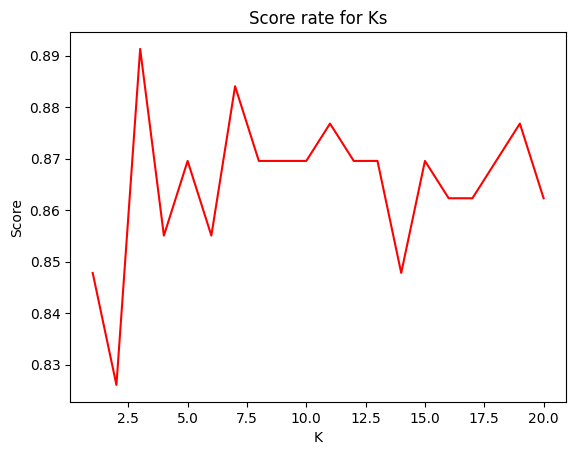

In [585]:
plt.plot(list(range(1,21)), list_of_scores, color= 'red')
plt.xlabel('K')
plt.ylabel('Score')
plt.title("Score rate for Ks")
plt.show()

In [586]:
scores = np.array(list_of_scores)
index_max = np.argmax(scores)
print(index_max)

2


Definition of KNN function

In [587]:
def euclidean_distance(x: np.ndarray,y: np.ndarray)-> float:
    return np.sqrt(np.sum((x-y)**2))

In [588]:
a1 = np.array([1,2,3])
a2 = np.array([1,1,1])
# a2 = np.array([44,76,34,12])

print(euclidean_distance(a1,a2))

2.23606797749979


In [589]:
def compute_distances(x_test_single: np.ndarray, x_train:np.ndarray)-> np.ndarray:        
    # list_of_distances = []
    # for item in x_train:
    #     list_of_distances.append(euclidean_distance(item,x_test_single))
    # mat = np.array(list_of_distances)
    # return mat
    return np.sqrt(np.sum((x_train - x_test_single)**2, axis=1))


In [590]:
b1 = np.array([1])
b2 = np.array([[-13],[21],[23],[5],[345],[57],[-44]])
list_of_distances = compute_distances(b1,b2)
print(list_of_distances)

[ 14.  20.  22.   4. 344.  56.  45.]


In [591]:
def get_k_nearest_indices(distances: np.ndarray, k: int)->np.ndarray:
    sorted_indices = np.argsort(distances)
    return sorted_indices[:k]

get_k_nearest_indices(list_of_distances,k=3)

array([3, 0, 1])

In [592]:
def get_most_common_label(y_nearest: np.ndarray):
    counts = np.bincount(y_nearest)
    return np.argmax(counts)

# def get_most_common_label(y_nearest: np.ndarray):
#     values, counts = np.unique(y_nearest, return_counts=True)
#     return values[np.argmax(counts)]


b = np.array([1, 0, 1, 1, 1,7,7,5,5,5,5,5,5])
get_most_common_label(b)


np.int64(5)

In [593]:
def predict_single_point(x_test_single, X_train, Y_train, k):
    distances = compute_distances(x_test_single=x_test_single, x_train=X_train)
    k_indices = get_k_nearest_indices(distances=distances,k=k)
    y_nearest = Y_train[np.array(k_indices)]
    return get_most_common_label(y_nearest=y_nearest)

In [594]:
X_train = np.array([
    [1, 1],
    [1, 2],
    [2, 1],
    [8, 8],
    [9, 8],
    [8, 9]
])

Y_train = np.array([0, 0, 0, 1, 1, 1])
k = 3


x_test_1 = np.array([2, 2]) 
predict_single_point(x_test_1, X_train, Y_train, k)


np.int64(0)

In [595]:
x_test_2 = np.array([7, 8]) 
predict_single_point(x_test_2, X_train, Y_train, k)


np.int64(1)